In [29]:
# импортируем нужные библиотеки
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau

from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from datasets import load_dataset
import numpy as np
import pandas as pd
import time
import re
import matplotlib.pyplot as plt
from collections import Counter

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

### Cкачивание и просмотр датасета

In [30]:
# 1. Загрузка датасета
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

# посмотрим 10 первых строк
dataset['train']['text'][:10]

['',
 ' = Valkyria Chronicles III = \n',
 '',
 ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n',
 " The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II . While it retained the standard features of the series , it also underwent multiple adjustments , such as making the game more f

In [31]:
# def shrink(split, fraction=0.1, seed=RANDOM_SEED):
#     num_samples = int(len(split) * fraction)
#     return split.shuffle(seed=seed).select(range(num_samples))

# shrunken_dataset = {
#     "train": shrink(dataset["train"]),
#     "validation": shrink(dataset["validation"]),
#     "test": shrink(dataset["test"]),
# }

# print(f"Original train size: {len(dataset['train'])} → {len(shrunken_dataset['train'])}")

# dataset = shrunken_dataset

In [32]:
# первое, что бросается в глаза - это пустые и бесполезные строки (например "= = Gameplay = = \n" или "")
# исключим их при предобработке

In [33]:
# 2. Очистка текстов
def clean_text(text):
    text = text.lower()  # к нижнему регистру
    text = re.sub(r"[^a-z0-9 ]+", " ", text)  # оставить только буквы и цифры
    text = re.sub(r"\s+", " ", text).strip()  # убрать дублирующиеся пробелы
    return text

cleaned_datasets = {}
min_words = 5

for split_name in ['train', 'validation', 'test']:
    texts = [clean_text(item['text']) for item in dataset[split_name]]
    texts = [t for t in texts if len(t.split()) >= min_words] # убираем пустые и мелкие тексты
    cleaned_datasets[split_name] = texts
    

train_clean = cleaned_datasets["train"]
val_clean = cleaned_datasets["validation"]
test_clean = cleaned_datasets["test"]


Статистика по количеству слов в тексте в датасете train:
Всего 17209 текстов
Среднее: 101.14
Медиана: 94.00
5-й перцентиль: 7.00
95-й перцентиль: 221.00
средняя длина предложения 584.130048230577


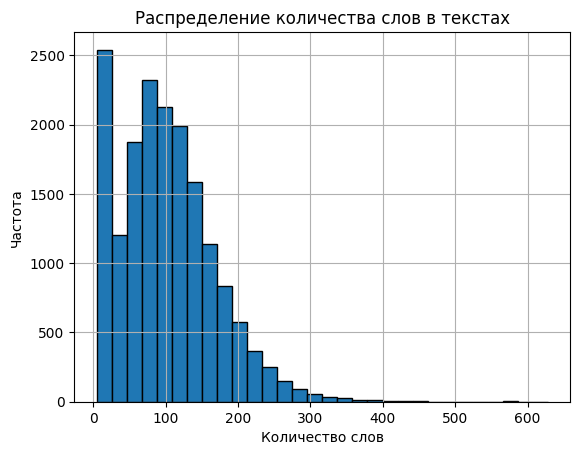


Статистика по количеству слов в тексте в датасете validation:
Всего 1823 текстов
Среднее: 100.04
Медиана: 95.00
5-й перцентиль: 7.00
95-й перцентиль: 214.00
средняя длина предложения 579.7048820625342


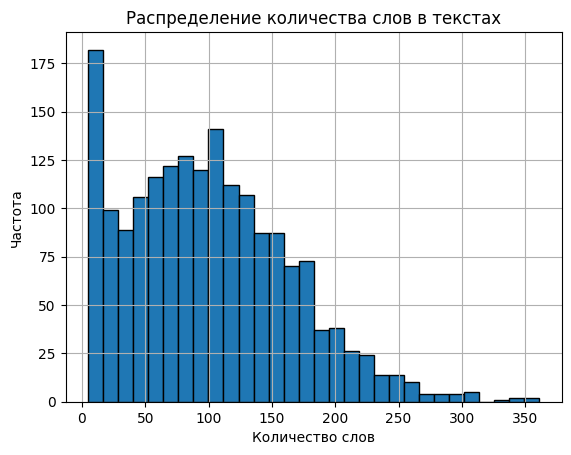


Статистика по количеству слов в тексте в датасете test:
Всего 2069 текстов
Среднее: 99.08
Медиана: 91.00
5-й перцентиль: 6.00
95-й перцентиль: 220.00
средняя длина предложения 573.3750604156597


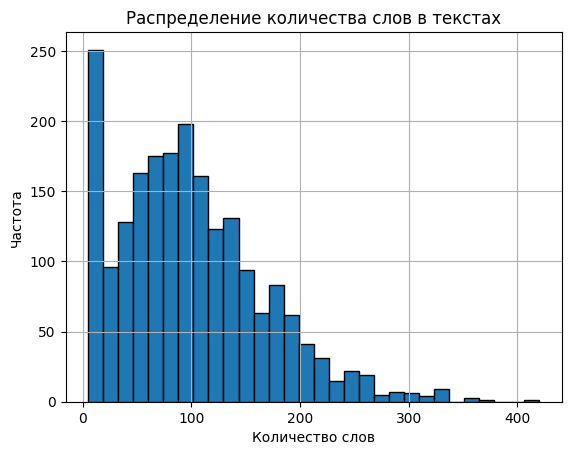

In [34]:
# посчитаем статистики
for split_name in ['train', 'validation', 'test']:
    ds = cleaned_datasets[split_name]

    # статистика по количеству слов
    word_counts = [len(text.split()) for text in ds]

    print(f"\nСтатистика по количеству слов в тексте в датасете {split_name}:")
    print(f"Всего {len(ds)} текстов")
    print(f"Среднее: {np.mean(word_counts):.2f}")
    print(f"Медиана: {np.median(word_counts):.2f}")
    print(f"5-й перцентиль: {np.percentile(word_counts, 5):.2f}")
    print(f"95-й перцентиль: {np.percentile(word_counts, 95):.2f}")
    print(f'средняя длина предложения {np.mean([len(x) for x in ds])}')

    # гистограмма распределения длины
    plt.hist(word_counts, bins=30, edgecolor='black')
    plt.title("Распределение количества слов в текстах")
    plt.xlabel("Количество слов")
    plt.ylabel("Частота")
    plt.grid(True)
    plt.show()

Вывод:

1. в целом тексты имеют примерно одинаковые метрики
2. есть множество текстов с очень маленькой длиной (6-10 слов)
3. в среднем в тексте не более 220 слов

In [35]:
# строим словарь на обучающей выборке

# считаем частоту всех слов
word_counts = Counter()
for text in train_clean:
    word_counts.update(text.split())

word_counts.most_common(10)

[('the', 130646),
 ('of', 56871),
 ('and', 50109),
 ('in', 44946),
 ('to', 39495),
 ('a', 36724),
 ('was', 21007),
 ('on', 15137),
 ('s', 15073),
 ('as', 15041)]

In [76]:
# пусть слово должно встретиться хотя бы 10 раз, чтобы попасть в словарь
min_freq = 10

# добавляем токены <UNK> для неизвестных слов, <PAD> для паддинга, '<BOS> и '<EOS>' для начала и конца предложения пока не делаем
# '<PAD>' будет иметь индекс 0 - нам это и нужно, т.к. в pad_sequence применим padding_value = 0
vocab_words = ['<PAD>', '<UNK>'] + [
    word for word, freq in word_counts.items() if freq >= min_freq
]

# словари для перевода "слово -> индекс" и "индекс -> слово"
word_to_idx = {word: idx for idx, word in enumerate(vocab_words)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}
vocab_size = len(vocab_words)

print(f"Размер словаря: {vocab_size}")
print(f"Пример: {list(word_to_idx.items())[:5]}")

Размер словаря: 13080
Пример: [('<PAD>', 0), ('<UNK>', 1), ('no', 2), ('valkyria', 3), ('3', 4)]


In [77]:
# параметры
seq_len = 64
batch_size = 64


# шаг 1
# пословная токенизация: заменяем все слова на индексы в словаре - получаем токены
def tokenize(text, word_to_idx, unk_token='<UNK>'):
    unk_idx = word_to_idx[unk_token]
    token_indices = [word_to_idx.get(word, unk_idx) for word in text.split()]
    return token_indices

# шаг 2
# берем текст в виде токенов и создаем из него несколько последовательностей из 32 токенов
# при этом останутся тексты или последовательности короче 32 токенов
def chunk_sequences(sequences, seq_len):
    chunks = []
    for seq in sequences:
        for i in range(0, len(seq), int(seq_len)):
            chunks.append(seq[i:i+seq_len])
    return chunks

# создаем класс chunkDataset, который будет возвращать фрагмент
class chunkDataset(Dataset):
    def __init__(self, texts):
        self.texts = texts

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        return {
            'text': torch.tensor(self.texts[idx], dtype=torch.long)
        }

# шаг 3
def collate_fn(batch):
    # список текстов из батча
    texts = [item['text'] for item in batch]

    # последовательности короче 32 токенов заполнятся 0
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=0)

    X = padded_texts[:, :-1]
    Y = padded_texts[:, 1:]

    masks = (padded_texts != 0).long()

    # PAD токены не участвуют в loss (в CrossEntropyLoss по умолчанию параметр ignore_index = -100)
    Y = Y.clone()
    Y[Y == 0] = -100

    # возвращаем преобразованный батч
    return {
        'texts': X,
        'masks': masks,
        'labels': Y
    }


# подготавливаем данные
train_tokenized = [tokenize(text, word_to_idx) for text in train_clean]
val_tokenized = [tokenize(text, word_to_idx) for text in val_clean]
test_tokenized = [tokenize(text, word_to_idx) for text in test_clean]

train_chunked = chunk_sequences(train_tokenized, seq_len)
val_chunked = chunk_sequences(val_tokenized, seq_len)
test_chunked = chunk_sequences(test_tokenized, seq_len)

train_dataset = chunkDataset(train_chunked)
val_dataset   = chunkDataset(val_chunked)
test_dataset  = chunkDataset(test_chunked)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

#### Выводы
Выполнена предобработка и подготовка текстов для моделей

1. Убраны бесполезные тексты
2. Удалены знаки препинания
3. Слова токенизированы
4. Тексты разбиты на последовательности по 32 токена в каждой

### Этап 2. Реализация и обучение LSTM

In [78]:
# если задача - предсказать следующее слово из словаря, то output_size = vocab_size, т.к. vocab_size содержит весь набор слов

class nextWordRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, output_size, dropout, model_type = 'LSTM'):
        super().__init__()
        self.model_type = model_type
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        if model_type == 'LSTM':
            self.model = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        else:
            self.model = nn.GRU(embedding_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_size)
        self.apply(self.init_weights)

    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, hidden = self.model(emb, hidden)
        out = self.norm(out)
        logits = self.fc(out)
        return logits, hidden
    
    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

In [79]:
def train_epoch(model, dataloader, optimizer, loss_fn, clip, device):
    model.train()
    total_loss = 0
    
    for batch in dataloader:
        X = batch['texts'].to(device)
        Y = batch['labels'].to(device)

        optimizer.zero_grad()
        logits, _ = model(X)
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), Y.reshape(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item() * X.size(0)
    return total_loss / len(dataloader.dataset)


def validate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            X = batch['texts'].to(device)
            Y = batch['labels'].to(device)

            logits, _ = model(X)

            loss = loss_fn(logits.reshape(-1, logits.size(-1)), Y.reshape(-1))
            total_loss += loss.item() * X.size(0)

    avg_loss = total_loss / len(dataloader.dataset)
    perplexity = torch.exp(torch.tensor(avg_loss)).item()
    return avg_loss, perplexity


def predict_next_words_rnn(model, text, word_to_idx, idx_to_word, device, top_k=3):
    model.eval()
    results = []
    token_ids = tokenize(text, word_to_idx)

    if len(token_ids) == 0:
        return []

    input_tensor = torch.tensor([token_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        logits, _ = model(input_tensor)

    next_token_logits = logits[:, -1, :]
    probs = torch.softmax(next_token_logits, dim=-1)
    top_probs, top_ids = torch.topk(probs, k=top_k, dim=-1)

    for token_id, prob in zip(top_ids[0], top_probs[0]):
        word = idx_to_word[token_id.item()]
        results.append((word, prob.item()))

    return results

In [ ]:
def get_results(model, scheduler, train_loader, val_loader, optimizer, loss_fn, clip, device, epochs):

    print(f"model: {model.model_type}")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    train_losses, val_losses, val_perplexities, train_time = [], [], [], []

    for epoch in range(epochs):
        start_time = time.time()

        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, clip, device)
        val_loss, val_ppl = validate(model, val_loader, loss_fn, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_perplexities.append(val_ppl)

        elapsed = time.time() - start_time
        train_time.append(elapsed)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Perplexity: {val_ppl:.2f} | lr = {current_lr:.6f} | elapsed {elapsed:.2f}s")

    # Построение графиков

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train')
    plt.plot(val_losses, label='Val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(val_perplexities, label='Perplexity')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        'name' : model.model_type,
        'train_losses' : train_losses,
        'val_losses' : val_losses,
        'val_perplexities' : val_perplexities,
        'train_time' : train_time,
        'final_info' : pd.DataFrame({
                                    'name': [model.model_type],
                                    'params': [sum(p.numel() for p in model.parameters())],
                                    'train_loss': [train_losses[-1]],
                                    'val_loss': [val_losses[-1]],
                                    'val_perplexity': [val_perplexities[-1]],
                                    'train_time': [sum(train_time)],
                                    'best_epoch': [val_perplexities.index(min(val_perplexities)) + 1],
                                    'best_perplexity': [min(val_perplexities)]
                                })
    }

In [88]:
# параметры для обучения
embedding_dim = 256
lr = 0.001
num_layers = 2
hidden_dim = 512
dropout = 0.3
clip = 1.0
epochs = 10
weight_decay = 0.01
vocab_size=vocab_size
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model: LSTM
Total parameters: 13,737,752
Epoch 1/10 | Train Loss: 6.7176 | Val Loss: 6.5014 | Val Perplexity: 666.05 | lr = 0.001000 | elapsed 48.84s
Epoch 2/10 | Train Loss: 6.6028 | Val Loss: 6.3659 | Val Perplexity: 581.69 | lr = 0.001000 | elapsed 49.24s
Epoch 3/10 | Train Loss: 6.5457 | Val Loss: 6.3510 | Val Perplexity: 573.04 | lr = 0.001000 | elapsed 49.10s
Epoch 4/10 | Train Loss: 6.5287 | Val Loss: 6.3378 | Val Perplexity: 565.55 | lr = 0.001000 | elapsed 48.98s
Epoch 5/10 | Train Loss: 6.5097 | Val Loss: 6.3145 | Val Perplexity: 552.54 | lr = 0.001000 | elapsed 49.03s
Epoch 6/10 | Train Loss: 6.4858 | Val Loss: 6.2877 | Val Perplexity: 537.93 | lr = 0.001000 | elapsed 49.06s
Epoch 7/10 | Train Loss: 6.4638 | Val Loss: 6.2687 | Val Perplexity: 527.79 | lr = 0.001000 | elapsed 49.02s
Epoch 8/10 | Train Loss: 6.4515 | Val Loss: 6.2677 | Val Perplexity: 527.24 | lr = 0.001000 | elapsed 49.03s
Epoch 9/10 | Train Loss: 6.4608 | Val Loss: 6.2810 | Val Perplexity: 534.31 | lr = 0.00

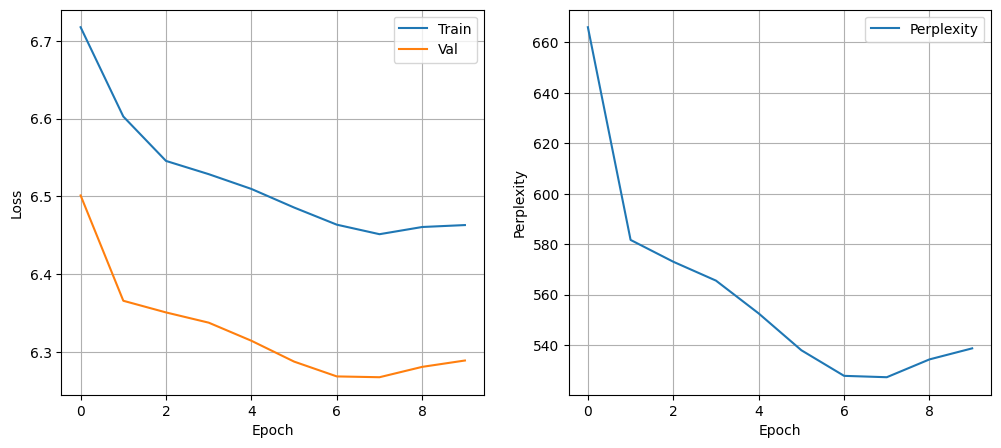

model: GRU
Total parameters: 12,818,200
Epoch 1/10 | Train Loss: 6.7131 | Val Loss: 6.4792 | Val Perplexity: 651.47 | lr = 0.001000 | elapsed 45.37s
Epoch 2/10 | Train Loss: 6.5829 | Val Loss: 6.3554 | Val Perplexity: 575.61 | lr = 0.001000 | elapsed 45.45s
Epoch 3/10 | Train Loss: 6.5274 | Val Loss: 6.3364 | Val Perplexity: 564.78 | lr = 0.001000 | elapsed 45.39s
Epoch 4/10 | Train Loss: 6.5097 | Val Loss: 6.3150 | Val Perplexity: 552.80 | lr = 0.001000 | elapsed 45.31s
Epoch 5/10 | Train Loss: 6.4920 | Val Loss: 6.3005 | Val Perplexity: 544.86 | lr = 0.001000 | elapsed 45.36s
Epoch 6/10 | Train Loss: 6.4650 | Val Loss: 6.2740 | Val Perplexity: 530.59 | lr = 0.001000 | elapsed 45.36s
Epoch 7/10 | Train Loss: 6.4361 | Val Loss: 6.2462 | Val Perplexity: 516.05 | lr = 0.001000 | elapsed 45.36s
Epoch 8/10 | Train Loss: 6.4201 | Val Loss: 6.2345 | Val Perplexity: 510.06 | lr = 0.001000 | elapsed 45.35s
Epoch 9/10 | Train Loss: 6.4238 | Val Loss: 6.2499 | Val Perplexity: 517.96 | lr = 0.001

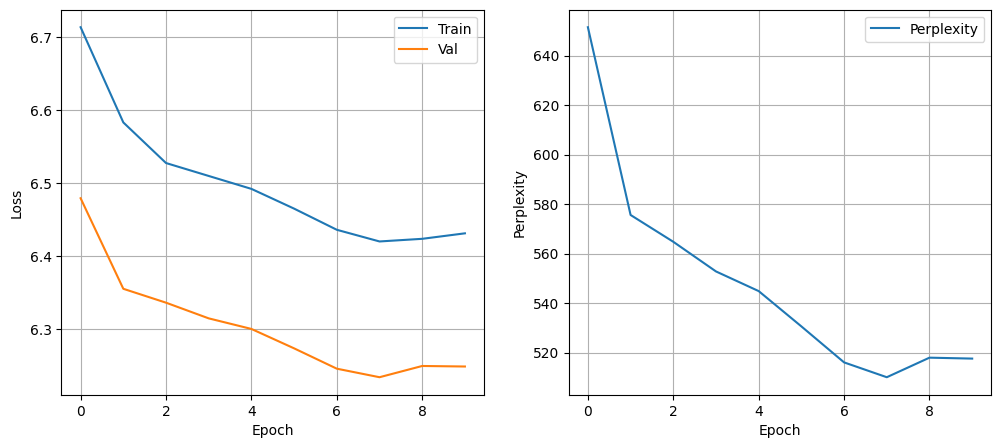

In [89]:
# модель lstm
lstm = nextWordRNN(
    vocab_size=vocab_size, 
    embedding_dim=embedding_dim, 
    hidden_dim=hidden_dim, 
    num_layers=num_layers, 
    output_size=vocab_size, 
    dropout=dropout, 
    model_type = 'LSTM'
    ).to(device)

# модель gru
gru = nextWordRNN(
    vocab_size=vocab_size, 
    embedding_dim=embedding_dim, 
    hidden_dim=hidden_dim, 
    num_layers=num_layers, 
    output_size=vocab_size, 
    dropout=dropout, 
    model_type = 'GRU'
    ).to(device)

loss_fn = nn.CrossEntropyLoss()

lstm_optimizer = Adam(lstm.parameters(), lr=lr, weight_decay=weight_decay)
lstm_scheduler = ReduceLROnPlateau(lstm_optimizer, mode='min', factor=0.5, patience=2)
lstm_result = get_results(lstm, lstm_scheduler, train_loader, val_loader, lstm_optimizer, loss_fn, clip, device, epochs)

gru_optimizer = Adam(gru.parameters(), lr=lr, weight_decay=weight_decay)
gru_scheduler = ReduceLROnPlateau(gru_optimizer, mode='min', factor=0.5, patience=2)
gru_result = get_results(gru, gru_scheduler, train_loader, val_loader, gru_optimizer, loss_fn, clip, device, epochs)

#### Выводы
1. Создан класс nextWordRNN с выбором типа сети - LSTM или GRU
2. Модели показали не очень высокий результат
3. Модель GRU обучается быстрее, имеет меньше параметров и при этом имеет лучшее качество

### Этап 3. Предобученный трансформер: distilgpt2

In [90]:
model_name = "distilgpt2"

gpt2_tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
distilgpt2 = GPT2LMHeadModel.from_pretrained(model_name).to(device)

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 6261.75it/s]


In [91]:
def gpt2_ppl(model, tokenizer, texts, device, stride):
    model.eval()

    # Склеиваем тексты в один длинный корпус
    full_text = "\n\n".join(texts)

    encodings = tokenizer(
        full_text,
        return_tensors="pt"
    )

    input_ids = encodings.input_ids.to(device)

    max_length = model.config.n_positions
    seq_len = input_ids.size(1)

    nlls = []
    prev_end_loc = 0

    with torch.no_grad():
        for begin_loc in range(0, seq_len, stride):
            end_loc = min(begin_loc + max_length, seq_len)
            trg_len = end_loc - prev_end_loc

            input_ids_chunk = input_ids[:, begin_loc:end_loc]

            target_ids = input_ids_chunk.clone()

            target_ids[:, :-trg_len] = -100

            outputs = model(
                input_ids_chunk,
                labels=target_ids
            )

            neg_log_likelihood = outputs.loss * trg_len
            nlls.append(neg_log_likelihood)

            prev_end_loc = end_loc

            if end_loc == seq_len:
                break

    avg_nll = torch.stack(nlls).sum() / end_loc
    perplexity = torch.exp(avg_nll).item()

    return pd.DataFrame({
                        'name': 'distilgpt2',
                        'params': [sum(p.numel() for p in model.parameters())],
                        'train_loss': np.nan,
                        'val_loss': avg_nll.item(),
                        'val_perplexity': perplexity,
                        'train_time': np.nan,
                        'best_epoch': np.nan,
                        'best_perplexity': np.nan
                    })


def predict_next_tokens_gpt2(model, tokenizer, text, device, top_k=3):
    model.eval()
    results = []

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    next_token_logits = outputs.logits[:, -1, :]
    probs = torch.softmax(next_token_logits, dim=-1)

    top_probs, top_ids = torch.topk(probs, k=top_k, dim=-1)


    for token_id, prob in zip(top_ids[0], top_probs[0]):
        token = tokenizer.decode([token_id.item()])
        results.append((token, prob.item()))

    return results

In [93]:
# прогон gpt2 на валидации и тесте
gpt2_result = gpt2_ppl(
    model=distilgpt2,
    tokenizer=gpt2_tokenizer,
    texts=val_clean,
    device=device,
    stride=128
)

gpt2_result_test = gpt2_ppl(
    model=distilgpt2,
    tokenizer=gpt2_tokenizer,
    texts=test_clean,
    device=device,
    stride=128
)

In [94]:
gpt2_result

,name,params,train_loss,val_loss,val_perplexity,train_time,best_epoch,best_perplexity
0,distilgpt2,81912576,NaN,4.317585,75.007233,NaN,NaN,NaN


#### Выводы
Модель DistilGPT2 из коробки показывает значительно более низкое значение Perplexity

### Этап 4. Сравнение результатов моделей

In [95]:
# сводная таблица по трем моделям на валидационной выборке
df = pd.concat([lstm_result.get('final_info'), gru_result.get('final_info')])
df = pd.concat([df, gpt2_result]).reset_index(drop=True)
df

,name,params,train_loss,val_loss,val_perplexity,train_time,best_epoch,best_perplexity
0,LSTM,13737752,6.463267,6.289146,538.693054,490.371203,8.0,527.243042
1,GRU,12818200,6.431257,6.249172,517.583923,453.723598,8.0,510.057648
2,distilgpt2,81912576,NaN,4.317585,75.007233,NaN,NaN,NaN


In [96]:
# на тесте
test_loss_lstm, test_ppl_lstm = validate(lstm, test_loader, loss_fn, device)
test_loss_gru,  test_ppl_gru  = validate(gru, test_loader, loss_fn, device)

print(f'test_loss_lstm {test_loss_lstm:.2f} | test_ppl_lstm {test_ppl_lstm:.2f}')
print(f'test_loss_gru  {test_loss_gru:.2f} | test_ppl_gru  {test_ppl_gru:.2f}')
print(f'test_loss_gpt2 {gpt2_result_test.val_loss[0]:.2f} | test_ppl_gpt2 {gpt2_result_test.val_perplexity[0]:.2f}')

test_loss_lstm 6.24 | test_ppl_lstm 513.01
test_loss_gru  6.20 | test_ppl_gru  491.12
test_loss_gpt2 4.29 | test_ppl_gpt2 73.01


In [97]:
# сделать предсказание по тексту из 32 слов и выдать топ-k следующих слов/токенов
def compare_predictions(texts, lstm, gru, distilgpt2, gpt2_tokenizer, word_to_idx, idx_to_word, device, top_k=5):
    rows = []

    for text in texts:
        lstm_preds = predict_next_words_rnn(
            model=lstm,
            text=text,
            word_to_idx=word_to_idx,
            idx_to_word=idx_to_word,
            device=device,
            top_k=top_k
        )

        gru_preds = predict_next_words_rnn(
            model=gru,
            text=text,
            word_to_idx=word_to_idx,
            idx_to_word=idx_to_word,
            device=device,
            top_k=top_k
        )

        gpt2_preds = predict_next_tokens_gpt2(
            model=distilgpt2,
            tokenizer=gpt2_tokenizer,
            text=text,
            device=device,
            top_k=top_k
        )

        rows.append({
            "lstm_top": ", ".join([f"{w}" for w, _ in lstm_preds]),
            "gru_top": ", ".join([f"{w}" for w, _ in gru_preds]),
            "distilgpt2_top": ", ".join([f"{repr(w)}" for w, _ in gpt2_preds])
        })

    return pd.DataFrame(rows)

In [98]:
examples = []
for i in range(15):
    t = ' '.join([idx_to_word.get(idx) for idx in test_chunked[i]])
    examples.append(t)


examples_to_add = []
for i in range(15):
    t = ' '.join([idx_to_word.get(idx) for idx in test_chunked[i+1]])
    examples_to_add.append(t[:15])

In [99]:
pd.set_option('display.max_colwidth', 100)

predictions_df = compare_predictions(
    texts=examples,
    lstm=lstm,
    gru=gru,
    distilgpt2=distilgpt2,
    gpt2_tokenizer=gpt2_tokenizer,
    word_to_idx=word_to_idx,
    idx_to_word=idx_to_word,
    device=device,
    top_k=5
)

# посмотрим на качество предсказаний моделей
predictions_df.insert(0, "correct_end", examples_to_add)
predictions_df

,correct_end,lstm_top,gru_top,distilgpt2_top
0,2004 <UNK> land,"the, <UNK>, a, his, their","the, <UNK>, a, his, its","' the', ' which', ' a', ' London', ' an'"
1,john <UNK> and,"the, <UNK>, a, his, an","the, <UNK>, a, his, an","' David', ' the', ' John', ' Michael', ' Peter'"
2,in 2006 <UNK> s,"of, and, in, to, <UNK>","<UNK>, and, of, in, to","' <', 'en', 'er', 'an', 'ow'"
3,2008 daylight r,"the, <UNK>, a, his, their","the, <UNK>, a, his, its","' the', ' 2006', ' 2007', ' which', ' 2005'"
4,fletcher <UNK>,"the, <UNK>, and, in, to","the, <UNK>, and, in, a","' and', ' par', ' he', ' the', '\n'"
5,in 2000 <UNK> h,"<UNK>, and, the, in, of","<UNK>, the, and, in, to","' and', ' starring', ' directed', '\n', ' for'"
6,role and he rec,"<UNK>, first, new, song, second","<UNK>, first, game, time, second","' play', ' episode', ' film', ' script', ' show'"
7,he had a recurr,"of, and, <UNK>, s, in","<UNK>, of, and, in, the","' <', '.', '<', '</', ' and'"
8,was performed a,"was, is, of, had, to","was, is, of, had, to","' was', ' is', ' had', ""'s"", ' has'"
9,<UNK> s hamlet,"the, <UNK>, to, in, and","the, <UNK>, in, and, to","' <', ' >', ',', ' in', ' and'"


#### Выводы
Модель на базе трансформера DistilGPT2 показывает значительно более низкие значения Perplexity, чем RNN-модели

Простые модели RNN способны предсказывать простые слова вроде "of" и "the", в то время как модель DistilGPT2 в топ-5 предсказаний иногда попадает в более трудные по смыслу закономерности

Для задачи предсказания следующего слова в мессенджере рекомендуется использовать DistilGPT2 как самую отчную модель из всех
______

ВОПРОС

В общем чате некоторые делились своими резкльтатами по данному проекту и получили результат PPL до 100. У меня значения сильно выше. Все из-за не совсем корректной предобработке данных? Если да, то как правильно нужно работать с текстами?